<a href="https://colab.research.google.com/github/NidhaIbrahim/LightHub/blob/main/LightHub_try_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LightHub Phishing Detection Model

## Objective

This notebook implements the machine learning pipeline used to train a
phishing URL detection model based on structural URL features.

The trained model will later be integrated into the LightHub browser
extension for real-time phishing detection.

## Research Development Process

During development, different preprocessing steps and feature sets were
tested to identify the most suitable configuration for phishing URL
detection.

Metadata features such as URLs and filenames were removed to avoid
potential data leakage and to ensure the model focuses only on
structural characteristics of URLs.

The final pipeline below represents the refined approach used for
training the model.

## Methodology

The model development pipeline consists of the following stages:

1 Dataset Acquisition  
2 Data Preprocessing  
3 Exploratory Analysis  
4 Handling Class Imbalance  
5 Feature Selection  
6 Model Training  
7 Model Evaluation  
8 Model Explainability  
9 Model Export

## 1 Dataset Acquisition

In [25]:
# Dataset acquisition

!pip install ucimlrepo shap imbalanced-learn

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Load the PhiUSIIL phishing URL dataset
dataset = fetch_ucirepo(id=967)

# Get feature data and target labels
X = dataset.data.features
y = dataset.data.targets

# Merge them into one dataframe for easier processing
df = pd.concat([X, y], axis=1)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset loaded: 235795 rows, 55 columns


## 2 Data Preprocessing

In [26]:
# Remove metadata columns like URL and filename
cols_to_drop = ['URL', 'FILENAME']

df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Drop rows with missing values
df_clean = df_clean.dropna()

## 3 Exploratory Analysis

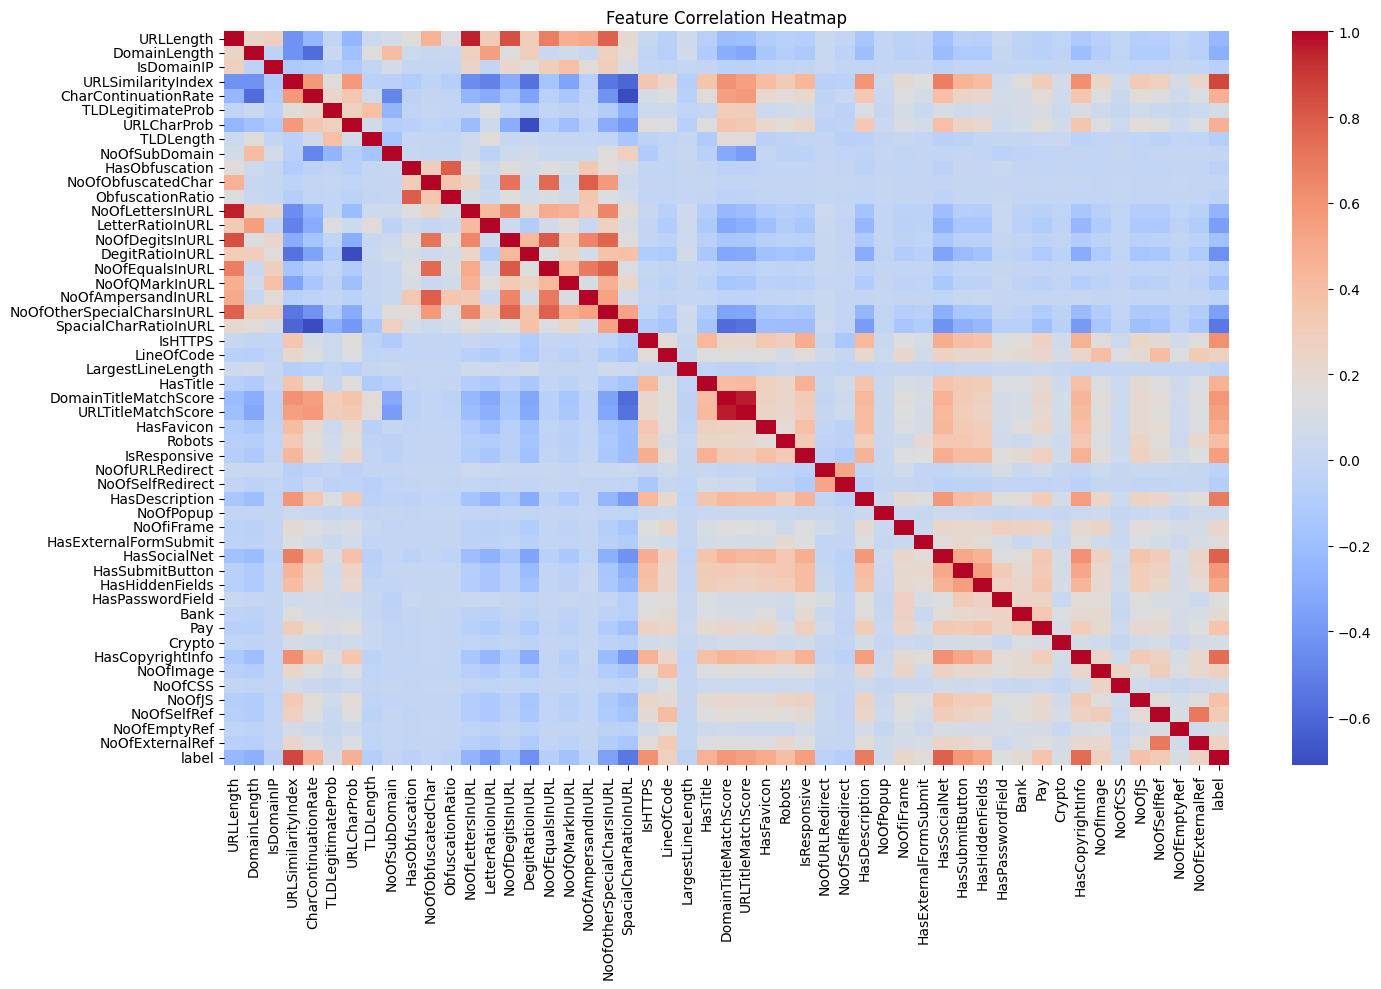

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate correlation matrix for numeric features
corr_matrix = df_clean.select_dtypes(include=['number']).corr()

# Plot correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 4 Handling Class Imbalance

In [28]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Separate features and label
X_raw = df_clean.drop('label', axis=1)
y_raw = df_clean['label']

print("Class distribution before balancing:", Counter(y_raw))

# Apply random undersampling to balance the classes
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_raw, y_raw)

print("Class distribution after balancing:", Counter(y_res))

Class distribution before balancing: Counter({1: 134850, 0: 100945})
Class distribution after balancing: Counter({0: 100945, 1: 100945})


## 5 Feature Selection

In [29]:
# Select numeric features from the balanced dataset
X_numeric = X_res.select_dtypes(include=['number'])

# Define heuristic URL features used for phishing detection
heuristic_features = [
    'URLLength', 'NoOfDotsInURL', 'NoOfHyphensInURL', 'NoOfAtSymbolInURL',
    'NoOfObfuscatedCharsInURL', 'NoOfLettersInURL', 'NoOfDegitsInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
    'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL',
    'LetterRatioInURL', 'DegitRatioInURL'
]

# Keep only the heuristic features that exist in the dataset
X_final = X_numeric[[col for col in heuristic_features if col in X_numeric.columns]]

print("Number of heuristic features used:", X_final.shape[1])

Number of heuristic features used: 10


## Correlation Analysis for Selected Features

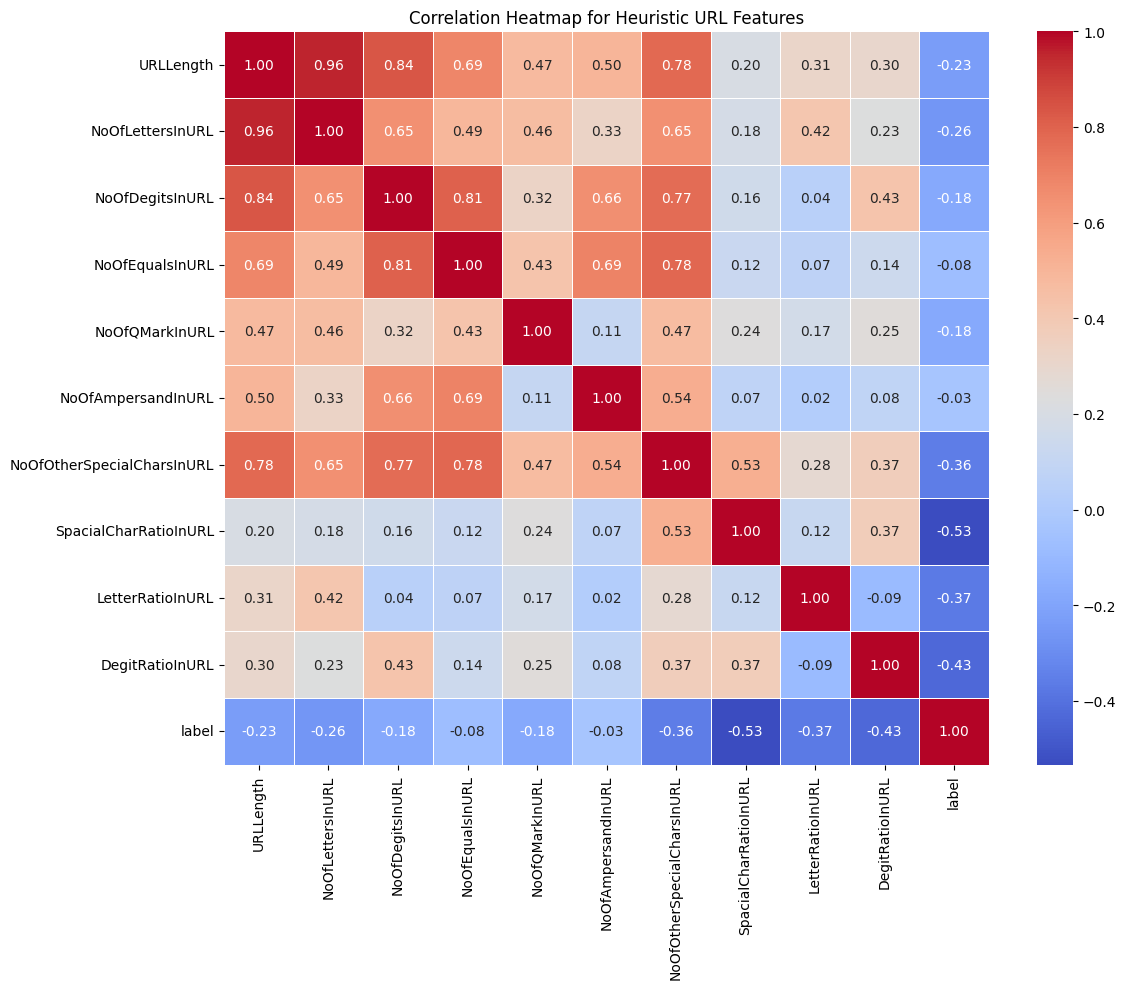

In [30]:
# Generate correlation heatmap for the selected heuristic features
import seaborn as sns
import matplotlib.pyplot as plt

# Select available heuristic features + label
safe_heatmap_cols = [col for col in heuristic_features if col in df_clean.columns] + ['label']

refined_df = df_clean[safe_heatmap_cols]
refined_corr = refined_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(refined_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap for Heuristic URL Features")
plt.tight_layout()
plt.show()

## 6 Model Training

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_res, test_size=0.2, random_state=42
)

# Train Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

## 7 Model Evaluation

Training on 10 heuristic features
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     20230
           1       0.77      0.97      0.86     20148

    accuracy                           0.84     40378
   macro avg       0.86      0.84      0.83     40378
weighted avg       0.87      0.84      0.83     40378



<Figure size 800x600 with 0 Axes>

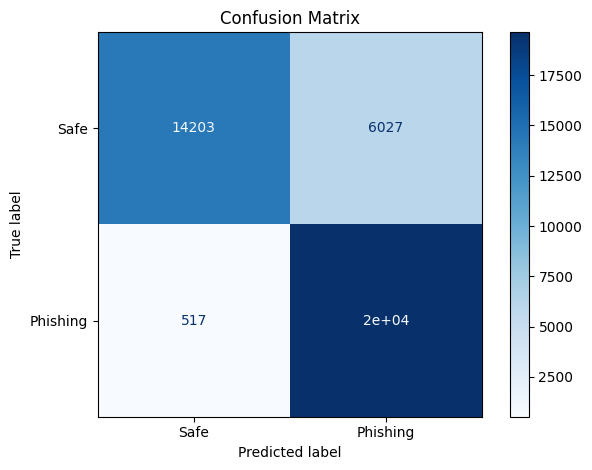

In [32]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
y_pred = model.predict(X_test)

print("Training on", X_train.shape[1], "heuristic features")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 8 Model Explainability

<Figure size 640x480 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

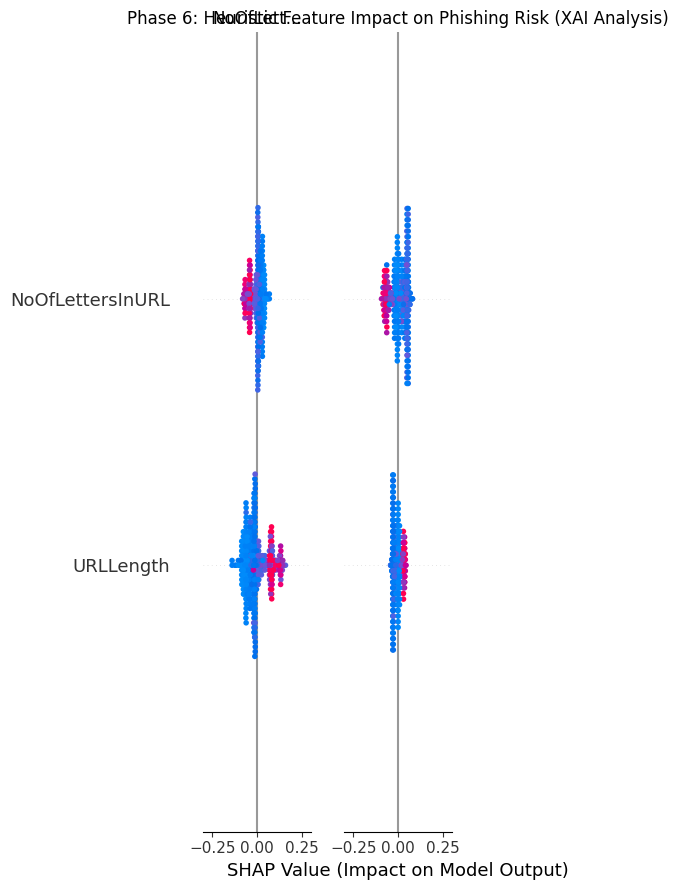

In [33]:
# SHAP analysis for model interpretability
import shap
import matplotlib.pyplot as plt

# 1. Complete Reset of the plotting engine
plt.close('all')
plt.clf()

# 2. Use the model from your successful 'Try 2' run
explainer = shap.TreeExplainer(model)

# 3. Use a sample of 500 rows
# This prevents the 'blob' effect and makes the dots look professional
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

# 4. Select the Phishing class (Class 1)
if isinstance(shap_values, list):
    final_shap = shap_values[1]
else:
    final_shap = shap_values

# 5. THE FIX: Define the plot size BEFORE calling shap
# We use a height of 10 to ensure all 14 features have vertical space
plt.figure(figsize=(12, 10))

shap.summary_plot(
    final_shap,
    X_sample,
    plot_type="dot",
    max_display=14, # Forces all 14 heuristics to show
    show=False
)

# 6. Final formatting for your thesis image
plt.title("Phase 6: Heuristic Feature Impact on Phishing Risk (XAI Analysis)")
plt.xlabel("SHAP Value (Impact on Model Output)")
plt.tight_layout()
plt.show()

## 9 Model Export

In [34]:
# Save trained model for LightHub browser extension

import joblib

joblib.dump(model, "lighthub_model.pkl")

# Save the feature list used during training
feature_names = list(X_train.columns)
joblib.dump(feature_names, "feature_list.pkl")

print("Model export complete")
print("Total features used:", len(feature_names))
print("Feature list:", feature_names)

# Download files from Colab
from google.colab import files
files.download("lighthub_model.pkl")
files.download("feature_list.pkl")

Model export complete
Total features used: 10
Feature list: ['URLLength', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'LetterRatioInURL', 'DegitRatioInURL']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>